### Univariate Analysis

### Adım 1 — Tanımlayıcı İstatistikler (Descriptive Statistics)

In [46]:
import pandas as pd

df = pd.read_csv('../data/raw/train.csv') 

df_clean = df.copy()

df_clean.head(3)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied


In [45]:
df_clean.drop(columns=["Unnamed: 0", "id"], inplace=True) 

KeyError: "['Unnamed: 0'] not found in axis"

In [51]:
df_clean.columns = (
    df_clean.columns
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('/', '_')
    .str.replace('-', '_')
)


print(df_clean.columns)


Index(['gender', 'customer_type', 'age', 'type_of_travel', 'class',
       'flight_distance', 'inflight_wifi_service',
       'departure_arrival_time_convenient', 'ease_of_online_booking',
       'gate_location', 'food_and_drink', 'online_boarding', 'seat_comfort',
       'inflight_entertainment', 'on_board_service', 'leg_room_service',
       'baggage_handling', 'checkin_service', 'inflight_service',
       'cleanliness', 'departure_delay_in_minutes', 'arrival_delay_in_minutes',
       'satisfaction'],
      dtype='object')


In [52]:
df_clean["arrival_delay_in_minutes"] = (df_clean["arrival_delay_in_minutes"].fillna(df_clean["departure_delay_in_minutes"]))

In [6]:
df_clean["age"].describe()

count    103904.000000
mean         39.379706
std          15.114964
min           7.000000
25%          27.000000
50%          40.000000
75%          51.000000
max          85.000000
Name: age, dtype: float64

Age Değişkeninin Tanımlayıcı İstatistikleri

İlk olarak age değişkeninin temel tanımlayıcı istatistikleri incelenmiştir. Bu analiz sayesinde yolcuların yaş dağılımının merkezi eğilim ve yayılım özellikleri değerlendirilmiştir.

In [7]:
print(f"Ortalama Yaş: {df_clean['age'].mean():.2f}")
print(f"Medyan Yaş: {df_clean['age'].median():.2f}")

Ortalama Yaş: 39.38
Medyan Yaş: 40.00


In [8]:
print(df_clean["age"].std())

15.114963699738569


In [9]:
print(df_clean["age"].skew())

-0.0045161270723468785


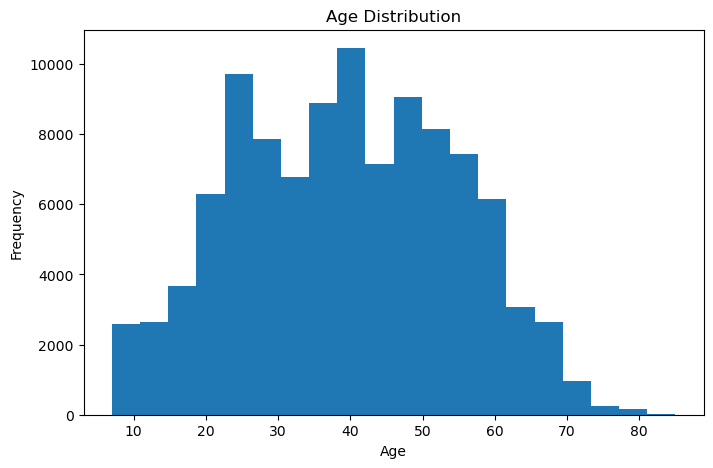

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_clean["age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

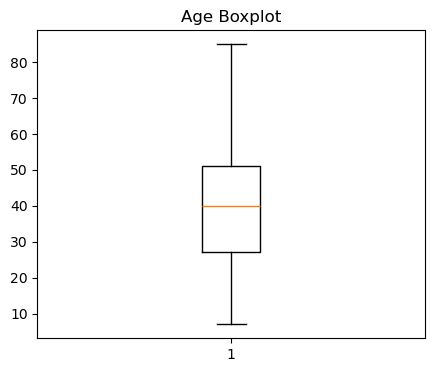

In [11]:
plt.figure(figsize=(5,4))
plt.boxplot(df_clean["age"])

plt.title("Age Boxplot")

plt.show()

Age Değişkeninin İncelenmesi

age değişkeninin dağılımı tanımlayıcı istatistikler, histogram, boxplot ve çarpıklık katsayısı kullanılarak incelenmiştir.

Tanımlayıcı istatistiklere göre veri setinde 103.904 yolcu bulunmaktadır. Yolcuların yaşları 7 ile 85 arasında değişmekte olup, ortalama yaş 39.38, medyan yaş ise 40 olarak hesaplanmıştır. Ortalama ve medyan değerlerinin birbirine oldukça yakın olması, yaş dağılımında belirgin bir çarpıklık bulunmadığını göstermektedir.

Yaş değişkeninin standart sapması 15.11 olarak hesaplanmıştır. Bu durum, yolcu yaşlarının ortalama etrafında orta düzeyde bir yayılım gösterdiğini ifade etmektedir. Ayrıca birinci çeyrek değer (Q1) 27, üçüncü çeyrek değer (Q3) ise 51 olarak hesaplanmış olup, yolcuların %50'sinin 27 ile 51 yaş aralığında yer aldığı görülmektedir.

Histogram incelendiğinde yaş dağılımının tek tepeye sahip olduğu ve yaklaşık simetrik bir yapı sergilediği gözlemlenmiştir. Boxplot grafiğinde de medyanın kutunun merkezine yakın konumlanması ve aykırı değer bulunmaması, bu dağılımı desteklemektedir.

Çarpıklık katsayısı -0.0045 olarak hesaplanmıştır. Bu değerin sıfıra oldukça yakın olması, yaş değişkeninin yaklaşık simetrik bir dağılıma sahip olduğunu göstermektedir.

Sonuç olarak, age değişkeni dengeli bir dağılım sergilemekte olup veri setinde herhangi bir anormal yapı gözlenmemiştir. Bu nedenle değişken, sonraki analizlerde doğrudan kullanılabilecek güvenilir bir değişken olarak değerlendirilmiştir.



In [12]:
df_clean["flight_distance"].describe()

count    103904.000000
mean       1189.448375
std         997.147281
min          31.000000
25%         414.000000
50%         843.000000
75%        1743.000000
max        4983.000000
Name: flight_distance, dtype: float64

In [13]:
print(f"Ortalama Uçuş Mesafesi: {df_clean['flight_distance'].mean():.2f}")
print(f"Medyan Uçuş Mesafesi: {df_clean['flight_distance'].median():.2f}")

Ortalama Uçuş Mesafesi: 1189.45
Medyan Uçuş Mesafesi: 843.00


In [14]:
print(df_clean["flight_distance"].std())

997.1472805289635


In [15]:
print(df_clean["flight_distance"].skew())

1.1094656676620138


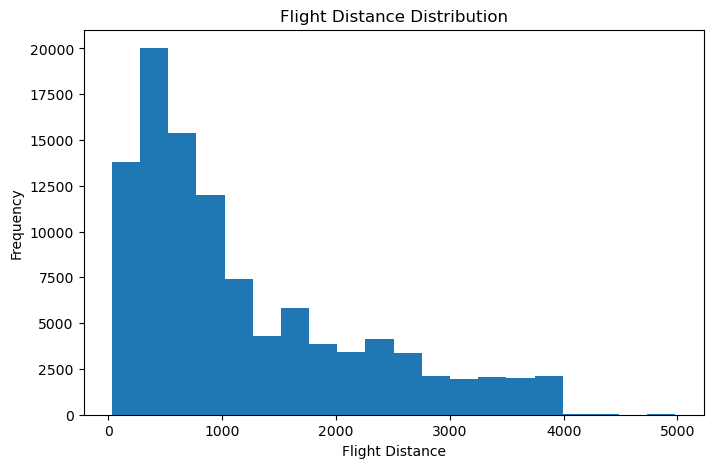

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_clean["flight_distance"], bins=20)

plt.title("Flight Distance Distribution")
plt.xlabel("Flight Distance")
plt.ylabel("Frequency")

plt.show()

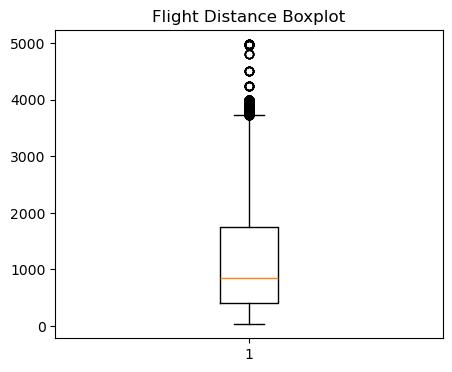

In [17]:
plt.figure(figsize=(5,4))
plt.boxplot(df_clean["flight_distance"])

plt.title("Flight Distance Boxplot")

plt.show()

Flight Distance Değişkeninin İncelenmesi

flight_distance değişkeninin dağılımı tanımlayıcı istatistikler, histogram, boxplot ve çarpıklık katsayısı kullanılarak incelenmiştir.

Tanımlayıcı istatistiklere göre veri setinde yer alan uçuş mesafeleri 31 km ile 4983 km arasında değişmektedir. Ortalama uçuş mesafesi 1189.45 km, medyan uçuş mesafesi ise 843 km olarak hesaplanmıştır. Ortalama değerin medyandan belirgin şekilde yüksek olması, uçuş mesafesi dağılımının sağa çarpık olduğuna işaret etmektedir.

Standart sapma 997.15 km olarak hesaplanmıştır. Bu durum, veri setinde kısa, orta ve uzun mesafeli uçuşların birlikte bulunması nedeniyle uçuş mesafelerinde yüksek bir değişkenlik olduğunu göstermektedir. Ayrıca birinci çeyrek değer (Q1) 414 km, üçüncü çeyrek değer (Q3) ise 1743 km olup, uçuşların %50'sinin bu aralıkta gerçekleştiği görülmektedir.

Histogram incelendiğinde kısa mesafeli uçuşların veri setinde daha yoğun olduğu, uçuş mesafesi arttıkça gözlem sayısının azaldığı ve dağılımın sağ tarafta uzun bir kuyruğa sahip olduğu görülmektedir. Boxplot grafiğinde ise üst sınırın üzerinde yer alan çok sayıda gözlem bulunmakta olup, bu durum uzun mesafeli uçuşların IQR yöntemine göre aykırı değer olarak değerlendirildiğini göstermektedir.

Çarpıklık katsayısı (Skewness = 1.109) dağılımın güçlü düzeyde sağa çarpık olduğunu doğrulamaktadır.

Sonuç olarak, flight_distance değişkeni simetrik bir dağılım göstermemektedir. Ancak tespit edilen yüksek mesafeli uçuşlar havacılık sektörünün doğal bir parçası olduğundan, bu gözlemler veri hatası olarak değerlendirilmemiş ve veri setinde korunmuştur.

In [19]:
df_clean["departure_delay_in_minutes"].describe()

count    103904.000000
mean         14.815618
std          38.230901
min           0.000000
25%           0.000000
50%           0.000000
75%          12.000000
max        1592.000000
Name: departure_delay_in_minutes, dtype: float64

In [21]:
print(f"Ortalama Departure Delay: {df_clean['departure_delay_in_minutes'].mean():.2f}")
print(f"Medyan Departure Delay: {df_clean['departure_delay_in_minutes'].median():.2f}")

Ortalama Departure Delay: 14.82
Medyan Departure Delay: 0.00


In [22]:
print(df_clean["departure_delay_in_minutes"].std())

38.23090058416843


In [23]:
print(df_clean["departure_delay_in_minutes"].skew())

6.733979510212754


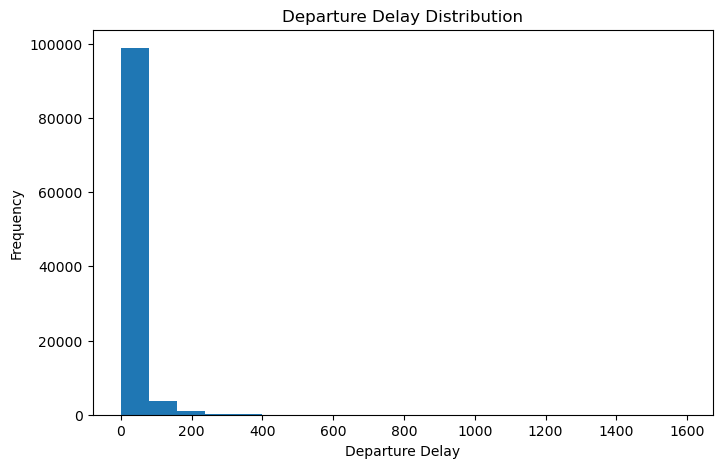

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_clean["departure_delay_in_minutes"], bins=20)

plt.title("Departure Delay Distribution")
plt.xlabel("Departure Delay")
plt.ylabel("Frequency")

plt.show()

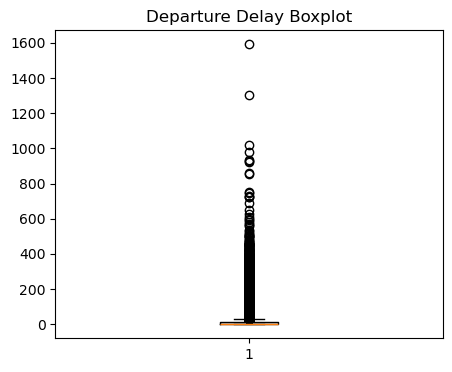

In [20]:
plt.figure(figsize=(5,4))
plt.boxplot(df_clean["departure_delay_in_minutes"])

plt.title("Departure Delay Boxplot")

plt.show()

Departure Delay Değişkeninin İncelenmesi

departure_delay_in_minutes değişkeni tanımlayıcı istatistikler, histogram, boxplot ve çarpıklık katsayısı kullanılarak incelenmiştir.

Tanımlayıcı istatistiklere göre kalkış gecikmeleri 0 ile 1592 dakika arasında değişmektedir. Ortalama gecikme süresi 14.82 dakika olarak hesaplanırken, medyan değerin 0 dakika olması dikkat çekmektedir. Bu durum, yolcuların en az yarısının herhangi bir kalkış gecikmesi yaşamadığını, buna karşın az sayıdaki yüksek gecikmenin ortalamayı yukarı çektiğini göstermektedir.

Standart sapma 38.23 dakika olup ortalama değerin oldukça üzerindedir. Bu sonuç, kalkış gecikmelerinin değişkenliğinin yüksek olduğunu ve bazı uçuşlarda olağan dışı gecikmeler yaşandığını göstermektedir. Ayrıca birinci çeyrek değer (Q1) 0 dakika, üçüncü çeyrek değer (Q3) ise 12 dakika olarak hesaplanmıştır. Buna göre uçuşların %75'i 12 dakika veya daha kısa gecikme ile gerçekleşmiştir.

Histogram incelendiğinde gözlemlerin büyük çoğunluğunun 0 dakika civarında yoğunlaştığı, gecikme süresi arttıkça gözlem sayısının hızla azaldığı ve dağılımın sağ tarafta uzun bir kuyruğa sahip olduğu görülmektedir. Boxplot grafiğinde ise çok sayıda aykırı değer yer almakta olup, özellikle yüksek gecikme süreleri IQR yöntemine göre aykırı değer olarak belirlenmiştir.

Çarpıklık katsayısı (Skewness = 6.734) dağılımın aşırı derecede sağa çarpık olduğunu göstermektedir. Bu sonuç, gecikme sürelerinin normal dağılım göstermediğini ve dağılımın az sayıdaki yüksek gecikmeden önemli ölçüde etkilendiğini doğrulamaktadır.

Bununla birlikte, havacılık sektöründe uzun süreli gecikmeler; olumsuz hava koşulları, teknik arızalar, hava trafiği yoğunluğu veya operasyonel aksaklıklar gibi nedenlerle gerçekleşebilmektedir. Bu nedenle yüksek gecikme süreleri veri hatası olarak değerlendirilmemiş, gerçek operasyonel olayları temsil ettiği kabul edilerek veri setinde korunmuştur.

In [36]:
df_clean["arrival_delay_in_minutes"].describe()

count    103904.000000
mean         15.245072
std          38.808674
min           0.000000
25%           0.000000
50%           0.000000
75%          13.000000
max        1584.000000
Name: arrival_delay_in_minutes, dtype: float64

In [37]:
print(f"Ortalama Arrival Delay: {df_clean['arrival_delay_in_minutes'].mean():.2f}")
print(f"Medyan Arrival Delay: {df_clean['arrival_delay_in_minutes'].median():.2f}")

Ortalama Arrival Delay: 15.25
Medyan Arrival Delay: 0.00


In [38]:
print(df_clean["arrival_delay_in_minutes"].std())

38.80867374963437


In [39]:
print(df_clean["arrival_delay_in_minutes"].skew())

6.564256704618242


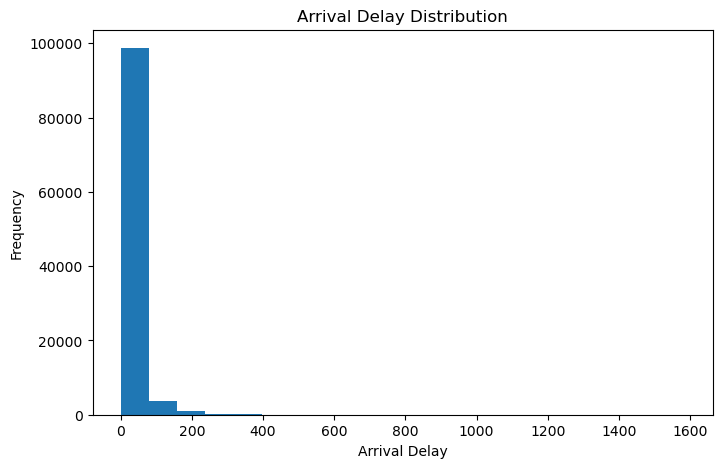

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_clean["arrival_delay_in_minutes"], bins=20)

plt.title("Arrival Delay Distribution")
plt.xlabel("Arrival Delay")
plt.ylabel("Frequency")

plt.show()

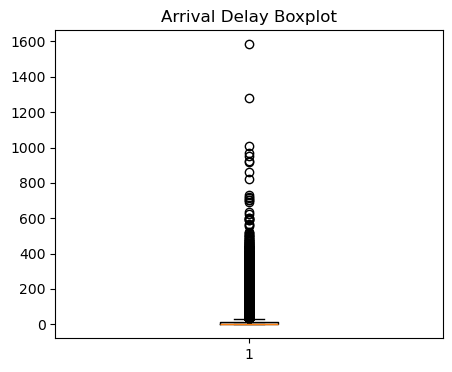

In [41]:
plt.figure(figsize=(5,4))
plt.boxplot(df_clean["arrival_delay_in_minutes"])

plt.title("Arrival Delay Boxplot")

plt.show()

Tanımlayıcı istatistiklere göre varış gecikmeleri 0 ile 1584 dakika arasında değişmektedir. Ortalama gecikme süresi 15.18 dakika, medyan gecikme süresi ise 0 dakika olarak hesaplanmıştır. Ortalama değerin medyandan belirgin şekilde yüksek olması, az sayıdaki yüksek gecikme değerinin ortalamayı yukarı çektiğini göstermektedir.

Standart sapma 38.70 dakika olup gecikme sürelerinin geniş bir aralıkta değiştiğini göstermektedir. Birinci çeyrek değer (Q1) 0 dakika, üçüncü çeyrek değer (Q3) ise 13 dakika olarak hesaplanmıştır. Bu durum, uçuşların %75'inin 13 dakika veya daha kısa gecikmeyle tamamlandığını göstermektedir.

Histogram incelendiğinde gözlemlerin büyük bölümünün 0 dakika veya düşük seviyeli gecikmelere sahip olduğu, gecikme süresi arttıkça gözlem sayısının hızla azaldığı görülmektedir. Dağılım sağ tarafta uzun bir kuyruk oluşturmakta ve birkaç uçuşun çok yüksek gecikme sürelerine sahip olduğu dikkat çekmektedir.

Boxplot grafiği de bu durumu desteklemektedir. Kutunun üst sınırının üzerinde çok sayıda aykırı değer bulunmakta olup, bu gözlemler uzun süreli gecikmeleri temsil etmektedir. Ancak havacılık sektöründe hava koşulları, hava trafiği yoğunluğu, teknik arızalar veya operasyonel aksaklıklar nedeniyle bu tür gecikmelerin gerçekleşmesi mümkün olduğundan, bu gözlemler veri hatası olarak değerlendirilmemiş ve veri setinde korunmuştur.

Çarpıklık katsayısı (Skewness = 6.597) dağılımın aşırı derecede sağa çarpık olduğunu göstermektedir. Bu sonuç, değişkenin normal dağılım varsayımını karşılamadığını ortaya koymaktadır.



### KATEGORİK DEĞİŞKEN ANALİZİ

In [7]:
df_clean["gender"].value_counts()

gender
Female    52727
Male      51177
Name: count, dtype: int64

In [8]:
df_clean["gender"].value_counts(normalize=True) * 100

gender
Female    50.745881
Male      49.254119
Name: proportion, dtype: float64

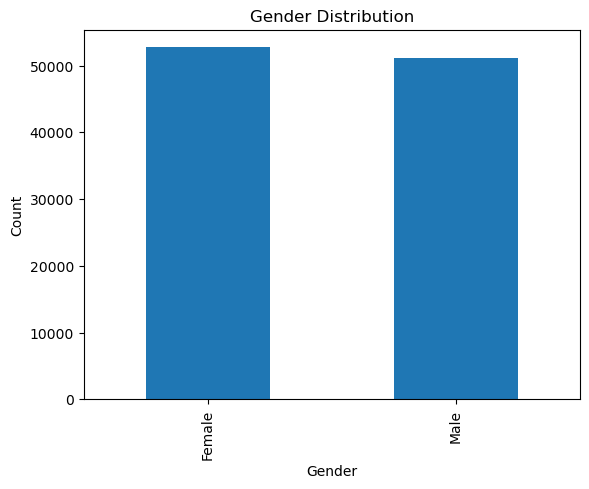

In [9]:
import matplotlib.pyplot as plt

df_clean["gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

Gender Değişkeninin İncelenmesi

Veri setindeki yolcuların cinsiyet dağılımı incelendiğinde kadın ve erkek yolcu sayılarının birbirine oldukça yakın olduğu görülmektedir. Bu durum veri setinin cinsiyet açısından dengeli olduğunu göstermektedir. Dolayısıyla sonraki analizlerde oluşabilecek farklılıkların yalnızca cinsiyet dağılımından kaynaklanmadığı söylenebilir.

In [10]:
df_clean["customer_type"].value_counts()

customer_type
Loyal Customer       84923
disloyal Customer    18981
Name: count, dtype: int64

In [11]:
df_clean["customer_type"].value_counts(normalize=True) * 100

customer_type
Loyal Customer       81.732176
disloyal Customer    18.267824
Name: proportion, dtype: float64

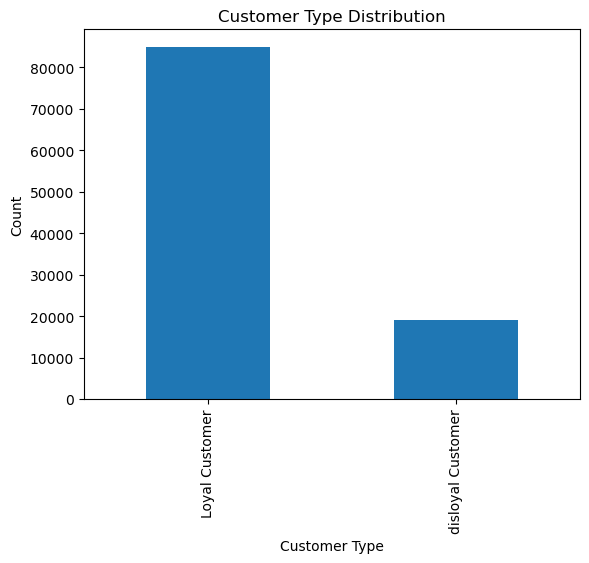

In [12]:
import matplotlib.pyplot as plt

df_clean["customer_type"].value_counts().plot(kind="bar")

plt.title("Customer Type Distribution")
plt.xlabel("Customer Type")
plt.ylabel("Count")
plt.show()

Customer Type Değişkeninin İncelenmesi

Veri setindeki yolcuların müşteri tipleri incelendiğinde, yolcuların %81,73'ünün Loyal Customer, %18,27'sinin ise disloyal Customer olduğu görülmektedir. Bu sonuç, veri setindeki yolcuların büyük çoğunluğunun havayolu şirketini daha önce de tercih eden sadık müşterilerden oluştuğunu göstermektedir.

İki grup arasında belirgin bir dengesizlik bulunmakla birlikte, her iki müşteri tipi de analiz yapılabilecek yeterli gözlem sayısına sahiptir. Bu nedenle ilerleyen aşamalarda müşteri tipinin memnuniyet üzerindeki etkisi güvenilir şekilde incelenebilecektir.

Müşteri sadakati, havacılık sektöründe müşteri deneyimini etkileyen önemli değişkenlerden biri olarak değerlendirilmektedir. Bu nedenle sonraki analizlerde sadık müşterilerin memnuniyet düzeylerinin diğer yolculara göre farklılaşıp farklılaşmadığı araştırılacaktır.

In [13]:
df_clean["type_of_travel"].value_counts()

type_of_travel
Business travel    71655
Personal Travel    32249
Name: count, dtype: int64

In [14]:
df_clean["type_of_travel"].value_counts(normalize=True) * 100

type_of_travel
Business travel    68.962696
Personal Travel    31.037304
Name: proportion, dtype: float64

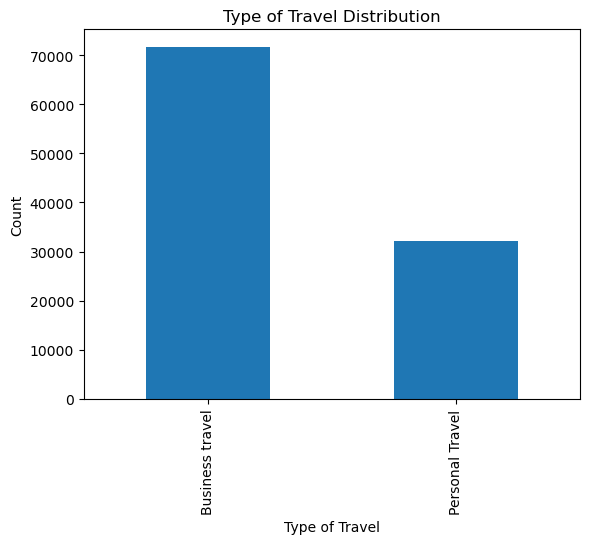

In [15]:
import matplotlib.pyplot as plt

df_clean["type_of_travel"].value_counts().plot(kind="bar")

plt.title("Type of Travel Distribution")
plt.xlabel("Type of Travel")
plt.ylabel("Count")
plt.show()

Type of Travel Değişkeninin İncelenmesi

Veri setindeki seyahat türleri incelendiğinde yolcuların %68,96'sının Business Travel, %31,04'ünün ise Personal Travel kapsamında seyahat ettiği görülmektedir. Buna göre veri setinde iş amaçlı seyahat eden yolcular çoğunluğu oluşturmaktadır.

İş seyahatleri ile kişisel seyahatlerin beklentileri farklılık gösterebildiğinden, bu değişken müşteri memnuniyetini etkileyebilecek önemli faktörlerden biri olarak değerlendirilmektedir. Özellikle iş amaçlı seyahat eden yolcuların zamanında kalkış, hizmet kalitesi ve operasyonel süreçlere daha fazla önem vermesi beklenmektedir.

Bu nedenle ilerleyen analizlerde seyahat amacının müşteri memnuniyeti üzerinde anlamlı bir farklılık oluşturup oluşturmadığı istatistiksel olarak incelenecektir.

In [16]:
df_clean["class"].value_counts()

class
Business    49665
Eco         46745
Eco Plus     7494
Name: count, dtype: int64

In [17]:
df_clean["class"].value_counts(normalize=True) * 100

class
Business    47.798930
Eco         44.988643
Eco Plus     7.212427
Name: proportion, dtype: float64

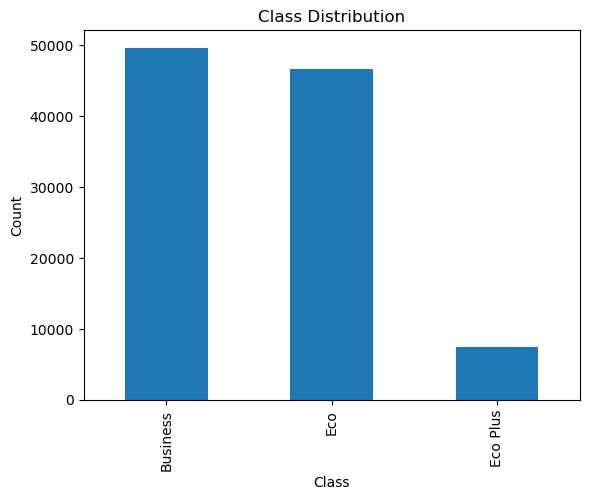

In [18]:
import matplotlib.pyplot as plt

df_clean["class"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Class Değişkeninin İncelenmesi

Veri setindeki uçuş sınıfları incelendiğinde yolcuların %47,80'inin Business Class, %44,99'unun Economy Class ve %7,21'inin Eco Plus sınıfında seyahat ettiği görülmektedir. Business ve Economy sınıflarındaki yolcu sayıları birbirine oldukça yakınken, Eco Plus sınıfının veri setinde daha düşük oranda temsil edildiği dikkat çekmektedir.

Farklı kabin sınıfları; koltuk konforu, ikram hizmetleri, bagaj hakları ve genel yolcu deneyimi açısından önemli farklılıklar sunmaktadır. Bu nedenle uçuş sınıfının müşteri memnuniyetini etkileyen temel değişkenlerden biri olması beklenmektedir.

İlerleyen analizlerde farklı uçuş sınıflarındaki yolcuların memnuniyet düzeyleri karşılaştırılarak bu değişken ile müşteri memnuniyeti arasındaki ilişkinin istatistiksel olarak anlamlı olup olmadığı değerlendirilecektir.

### SATISFACTION DEGERLENDIRMESI 

In [19]:
df_clean["satisfaction"].value_counts()

satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64

In [20]:
df_clean["satisfaction"].value_counts(normalize=True)*100

satisfaction
neutral or dissatisfied    56.666731
satisfied                  43.333269
Name: proportion, dtype: float64

## Satisfaction Değişkeninin İncelenmesi

Veri setindeki müşteri memnuniyeti dağılımı incelendiğinde yolcuların **%56,67'sinin** "neutral or dissatisfied", **%43,33'ünün** ise "satisfied" grubunda yer aldığı görülmektedir.

Her ne kadar memnun olmayan yolcu sayısı daha yüksek olsa da iki sınıf arasında aşırı bir dengesizlik bulunmamaktadır. Bu durum, memnuniyet üzerine gerçekleştirilecek karşılaştırmalı analizler ve istatistiksel testler için uygun bir veri dağılımı sağlamaktadır.

Bu değişken çalışmanın temel hedef değişkeni olup, sonraki bölümlerde diğer tüm değişkenlerin müşteri memnuniyeti üzerindeki etkisi ayrıntılı olarak incelenecektir.

In [21]:
pd.crosstab(df_clean["class"], df_clean["satisfaction"])

satisfaction,neutral or dissatisfied,satisfied
class,,
Business,15185,34480
Eco,38044,8701
Eco Plus,5650,1844


In [22]:
pd.crosstab(
    df_clean["class"],
    df_clean["satisfaction"],
    normalize="index"
)*100

satisfaction,neutral or dissatisfied,satisfied
class,,
Business,30.574852,69.425148
Eco,81.386245,18.613755
Eco Plus,75.393648,24.606352


<Axes: xlabel='class', ylabel='count'>

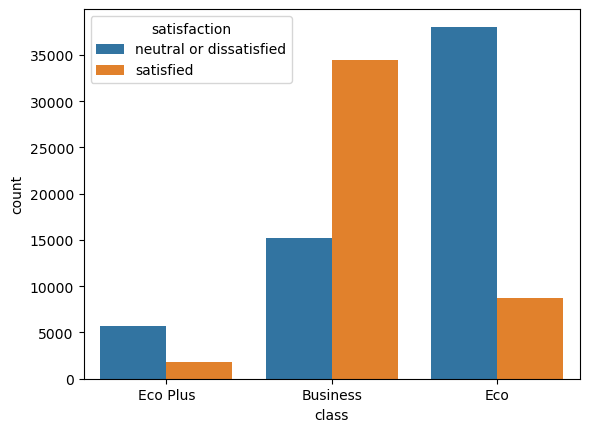

In [23]:
import seaborn as sns

sns.countplot(
    data=df_clean,
    x="class",
    hue="satisfaction"
)

## Class Değişkeni ile Müşteri Memnuniyeti Arasındaki İlişkinin İncelenmesi

Uçuş sınıfı ile müşteri memnuniyeti arasındaki ilişki incelendiğinde, sınıflar arasında belirgin farklılıklar olduğu görülmektedir.

Business Class yolcularının **%69,43'ü** uçuş deneyiminden memnun olduğunu belirtirken, **%30,57'si** memnun olmadığını ifade etmiştir. Buna karşılık Economy Class yolcularında memnuniyet oranı yalnızca **%18,61** olarak hesaplanmıştır. Eco Plus sınıfında ise memnuniyet oranı **%24,61** seviyesinde kalmıştır.

Elde edilen bulgular, Business Class yolcularının diğer sınıflara kıyasla çok daha yüksek memnuniyet düzeyine sahip olduğunu göstermektedir. Business sınıfında sunulan daha geniş koltuklar, öncelikli hizmetler, gelişmiş ikram seçenekleri ve daha konforlu seyahat deneyimi bu sonucun temel nedenleri arasında değerlendirilebilir.

Öte yandan Economy ve Eco Plus sınıflarında memnun olmayan yolcu oranının oldukça yüksek olması, müşteri memnuniyetini artırmaya yönelik iyileştirmelerin özellikle bu sınıflarda daha kritik olduğunu göstermektedir.

Bu bulgular doğrultusunda uçuş sınıfının müşteri memnuniyetini etkileyen önemli değişkenlerden biri olduğu düşünülmektedir. Ancak bu ilişkinin istatistiksel olarak anlamlı olup olmadığı ilerleyen aşamada Ki-Kare Bağımsızlık Testi ile değerlendirilecektir.

In [24]:
pd.crosstab(df_clean["customer_type"], df_clean["satisfaction"])

satisfaction,neutral or dissatisfied,satisfied
customer_type,,
Loyal Customer,44390,40533
disloyal Customer,14489,4492


In [27]:
pd.crosstab(
    df_clean["customer_type"],
    df_clean["satisfaction"],
    normalize="index"
)*100

satisfaction,neutral or dissatisfied,satisfied
customer_type,,
Loyal Customer,52.270881,47.729119
disloyal Customer,76.334229,23.665771


<Axes: xlabel='customer_type', ylabel='count'>

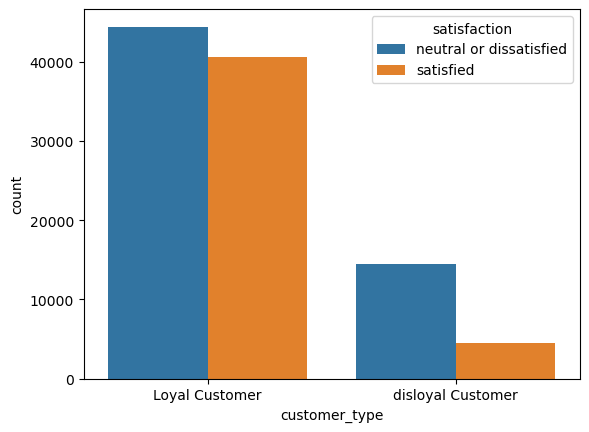

In [29]:
import seaborn as sns

sns.countplot(
    data=df_clean,
    x="customer_type",
    hue="satisfaction"
)

## Customer Type Değişkeni ile Müşteri Memnuniyeti Arasındaki İlişkinin İncelenmesi

Müşteri tipi ile memnuniyet arasındaki ilişki incelendiğinde, sadık müşteriler ile yeni müşteriler arasında belirgin farklılıklar olduğu görülmektedir.

Loyal Customer grubundaki yolcuların **%47,73'ü** memnun olduğunu belirtirken, **%52,27'si** memnun olmadığını ifade etmiştir. Buna karşılık disloyal Customer grubunda memnuniyet oranı yalnızca **%23,67** seviyesinde kalırken, yolcuların **%76,33'ü** memnun olmadığını belirtmiştir.

Bu sonuçlar, havayolu şirketini düzenli olarak tercih eden müşterilerin memnuniyet düzeylerinin, yeni veya sadık olmayan müşterilere göre daha yüksek olduğunu göstermektedir. Bunun nedenlerinden biri, sadık müşterilere sunulan ek avantajlar, puan programları veya ayrıcalıklı hizmetler olabilir. Ayrıca daha önce aynı havayolunu tercih etmiş müşterilerin hizmet süreçlerine aşina olmaları da memnuniyet düzeyini olumlu yönde etkileyebilir.

Bununla birlikte, sadık müşteriler arasında dahi memnun olmayan yolcuların oranının %50'nin üzerinde olması dikkat çekmektedir. Bu durum, müşteri sadakatinin tek başına memnuniyeti garanti etmediğini ve operasyonel hizmet kalitesinin önemini koruduğunu göstermektedir.

İlerleyen aşamada müşteri tipi ile memnuniyet arasındaki ilişkinin istatistiksel olarak anlamlı olup olmadığı Ki-Kare Bağımsızlık Testi ile incelenecektir.

In [30]:
pd.crosstab(df_clean["type_of_travel"], df_clean["satisfaction"])

satisfaction,neutral or dissatisfied,satisfied
type_of_travel,,
Business travel,29909,41746
Personal Travel,28970,3279


In [31]:
pd.crosstab(
    df_clean["type_of_travel"],
    df_clean["satisfaction"],
    normalize="index"
)*100

satisfaction,neutral or dissatisfied,satisfied
type_of_travel,,
Business travel,41.740283,58.259717
Personal Travel,89.832243,10.167757


<Axes: xlabel='type_of_travel', ylabel='count'>

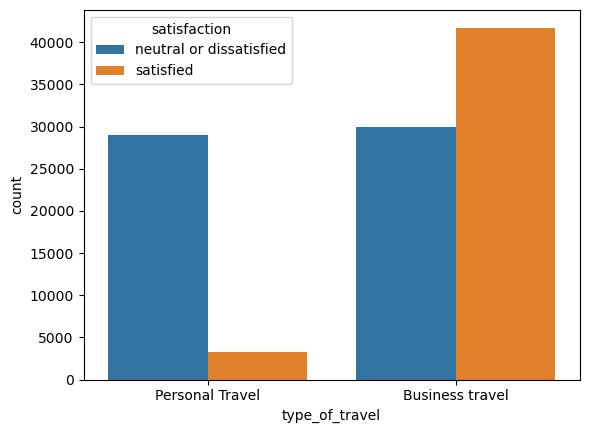

In [32]:
import seaborn as sns

sns.countplot(
    data=df_clean,
    x="type_of_travel",
    hue="satisfaction"
)

## Type of Travel Değişkeni ile Müşteri Memnuniyeti Arasındaki İlişkinin İncelenmesi

Seyahat amacı ile müşteri memnuniyeti arasındaki ilişki incelendiğinde oldukça belirgin bir farklılık gözlenmiştir.

Business Travel amacıyla seyahat eden yolcuların **%58,26'sı** uçuş deneyiminden memnun olduğunu belirtirken, **%41,74'ü** memnun olmadığını ifade etmiştir. Buna karşılık Personal Travel grubunda memnuniyet oranı yalnızca **%10,17** olarak hesaplanmış, yolcuların **%89,83'ü** memnun olmadığını belirtmiştir.

Bu sonuçlar, iş amaçlı seyahat eden yolcuların kişisel amaçla seyahat eden yolculara göre çok daha yüksek memnuniyet düzeyine sahip olduğunu göstermektedir.

Bu farklılığın oluşmasında iş seyahatlerinin büyük ölçüde Business Class ile ilişkilendirilmesi, şirket tarafından karşılanan hizmetler veya daha esnek uçuş seçenekleri gibi faktörlerin etkili olabileceği düşünülmektedir. Buna karşılık kişisel seyahatlerde fiyat odaklı tercihler ve Economy sınıfında seyahat etme oranının daha yüksek olması memnuniyet düzeyini olumsuz etkileyebilir.

Seyahat amacı ile müşteri memnuniyeti arasında güçlü bir ilişki olduğu gözlemlenmekle birlikte, bu ilişkinin istatistiksel olarak anlamlı olup olmadığı Ki-Kare Bağımsızlık Testi ile değerlendirilecektir.

In [33]:
pd.crosstab(df_clean["gender"], df_clean["satisfaction"])

satisfaction,neutral or dissatisfied,satisfied
gender,,
Female,30193,22534
Male,28686,22491


In [34]:
pd.crosstab(
    df_clean["gender"],
    df_clean["satisfaction"],
    normalize="index"
)*100

satisfaction,neutral or dissatisfied,satisfied
gender,,
Female,57.262882,42.737118
Male,56.052524,43.947476


<Axes: xlabel='gender', ylabel='count'>

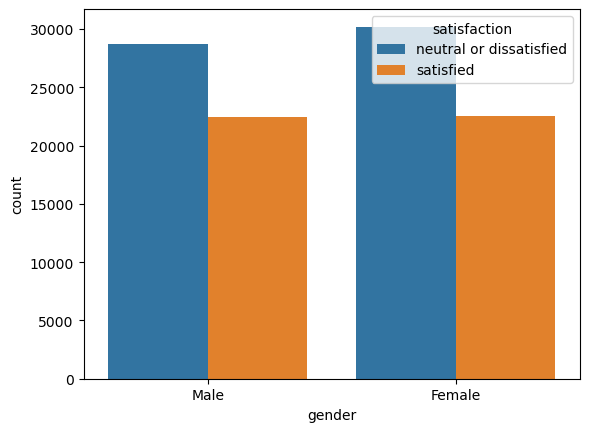

In [35]:
import seaborn as sns

sns.countplot(
    data=df_clean,
    x="gender",
    hue="satisfaction"
)

## Gender Değişkeni ile Müşteri Memnuniyeti Arasındaki İlişkinin İncelenmesi

Cinsiyet ile müşteri memnuniyeti arasındaki ilişki incelendiğinde kadın ve erkek yolcular arasında oldukça benzer memnuniyet oranları olduğu görülmektedir.

Kadın yolcuların **%42,74'ü** memnun olduğunu belirtirken, erkek yolcularda bu oran **%43,95** olarak hesaplanmıştır. Memnun olmayan yolcu oranları ise kadınlarda **%57,26**, erkeklerde ise **%56,05** seviyesindedir.

Elde edilen sonuçlar, kadın ve erkek yolcuların müşteri memnuniyeti açısından birbirine oldukça benzer bir dağılım sergilediğini göstermektedir. Gruplar arasındaki fark yaklaşık **1 puan** seviyesinde olup pratik açıdan oldukça düşüktür.

Bu nedenle ilk incelemeler, müşteri memnuniyetinin cinsiyetten ziyade hizmet kalitesi, uçuş sınıfı, gecikmeler veya seyahat amacı gibi operasyonel faktörlerden daha fazla etkilendiğine işaret etmektedir.

Yine de gözlenen küçük farkın istatistiksel olarak anlamlı olup olmadığı Ki-Kare Bağımsızlık Testi ile doğrulanacaktır.

### 4. Sayısal değişkenleri Satisfaction'a göre inceleye

Memnun olan yolcular daha uzun uçuşlar mı yapıyor?

### Flight Distance Değişkeninin Satisfaction ile İlişkisi

Bu bölümde uçuş mesafesinin (Flight Distance) müşteri memnuniyeti ile ilişkisi incelenmiştir.

Boxplot grafiği incelendiğinde memnun olan yolcuların uçuş mesafelerinin genel olarak daha yüksek olduğu görülmektedir. Kutunun (IQR) ve medyanın memnun olan yolcular grubunda daha yukarıda yer alması, bu grubun daha uzun mesafeli uçuşlar gerçekleştirdiğini göstermektedir. Ayrıca her iki grupta da uzun mesafeli uçuşlara ait aykırı değerler bulunmasına rağmen, memnun olan yolcuların dağılımı daha geniş bir aralığa yayılmaktadır.

Tanımlayıcı istatistikler de bu gözlemi desteklemektedir:

- Memnun olmayan yolcuların ortalama uçuş mesafesi **928.92 km**, memnun olan yolcuların ise **1530.14 km**'dir.
- Medyan uçuş mesafesi memnun olmayan yolcularda **671 km**, memnun olan yolcularda ise **1250 km** olarak hesaplanmıştır.
- Memnun olan yolcularda standart sapmanın (**1128.13 km**) memnun olmayan yolculara (**790.45 km**) göre daha yüksek olması, bu grubun çok daha geniş bir uçuş mesafesi aralığını kapsadığını göstermektedir.

Grafik ve özet istatistikler birlikte değerlendirildiğinde, daha uzun mesafeli uçuş yapan yolcuların memnuniyet düzeylerinin daha yüksek olma eğiliminde olduğu gözlenmektedir. Ancak bu durumun doğrudan uçuş mesafesinden kaynaklandığını söylemek doğru olmayacaktır. Uzun mesafeli uçuşların çoğunlukla Business sınıfı, sadık müşteri profili veya iş amaçlı seyahat gibi diğer değişkenlerle ilişkili olabileceği göz önünde bulundurulmalıdır.

Bu nedenle uçuş mesafesi ile müşteri memnuniyeti arasındaki ilişkinin istatistiksel olarak anlamlı olup olmadığı ve diğer değişkenlerden bağımsız bir etkiye sahip olup olmadığı ilerleyen aşamalarda uygulanacak hipotez testleri ve çok değişkenli analizler ile doğrulanacaktır.

<Axes: xlabel='satisfaction', ylabel='flight_distance'>

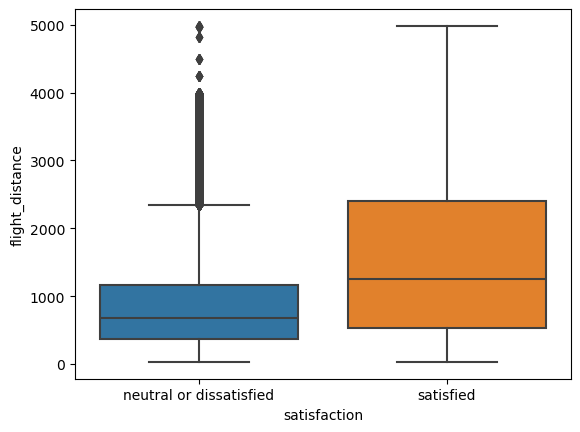

In [36]:
sns.boxplot(
    data=df_clean,
    x="satisfaction",
    y="flight_distance"
)

In [41]:
df_clean.groupby("satisfaction")["flight_distance"].describe()

,count,mean,std,min,25%,50%,75%,max
satisfaction,,,,,,,,
neutral or dissatisfied,58879.0,928.919971,790.452308,31.0,372.0,671.0,1158.0,4983.0
satisfied,45025.0,1530.140255,1128.126574,31.0,526.0,1250.0,2405.0,4983.0


Gecikme memnuniyeti gerçekten düşürüyor mu?
### Departure Delay Değişkeninin Satisfaction ile İlişkisi

Bu bölümde kalkış gecikmesi süresinin (Departure Delay) müşteri memnuniyeti ile ilişkisi incelenmiştir.

Boxplot grafiği incelendiğinde her iki grupta da yolcuların büyük çoğunlüğünün düşük gecikme sürelerine sahip olduğu görülmektedir. Bununla birlikte, memnun olmayan yolcuların gecikme sürelerinin daha geniş bir aralığa yayıldığı ve yüksek gecikme sürelerini temsil eden aykırı değerlerin bu grupta daha yoğun olduğu dikkat çekmektedir.

Tanımlayıcı istatistikler de bu gözlemi desteklemektedir:

- Memnun olmayan yolcuların ortalama kalkış gecikmesi **16.50 dakika**, memnun olan yolcuların ise **12.61 dakika**dır.
- Her iki grupta da medyan kalkış gecikmesi **0 dakika** olup, yolcuların en az yarısının herhangi bir kalkış gecikmesi yaşamadığını göstermektedir.
- Memnun olmayan yolcularda standart sapmanın (**40.19**) memnun olan yolculara (**35.38**) göre daha yüksek olması, gecikme sürelerinin bu grupta daha değişken olduğunu göstermektedir.
- Her iki grupta da maksimum gecikme süreleri oldukça yüksek olmasına rağmen, memnun olmayan yolcular daha uzun süreli gecikmelere maruz kalmıştır.

Grafik ve özet istatistikler birlikte değerlendirildiğinde, kalkış gecikmesi arttıkça müşteri memnuniyetinin azalma eğiliminde olduğu görülmektedir. Özellikle uzun süreli kalkış gecikmeleri, memnun olmayan yolcular arasında daha sık gözlenmektedir.

Ancak bu bulgular keşifsel veri analizi kapsamında elde edilmiştir. Kalkış gecikmesi ile müşteri memnuniyeti arasındaki ilişkinin istatistiksel olarak anlamlı olup olmadığını belirlemek amacıyla ilerleyen aşamalarda uygun hipotez testleri uygulanacaktır.


<Axes: xlabel='satisfaction', ylabel='departure_delay_in_minutes'>

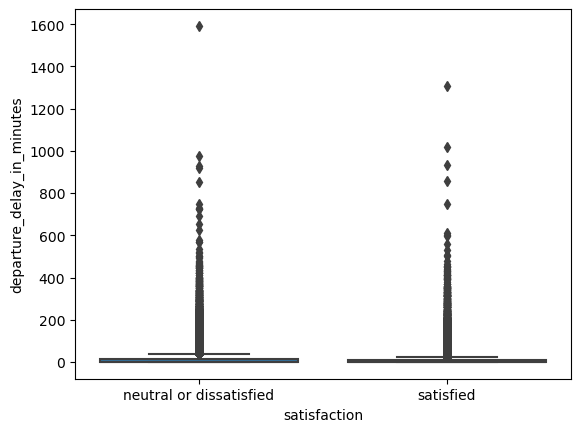

In [37]:
sns.boxplot(
    data=df_clean,
    x="satisfaction",
    y="departure_delay_in_minutes"
)

In [40]:
df_clean.groupby("satisfaction")["departure_delay_in_minutes"].describe()

,count,mean,std,min,25%,50%,75%,max
satisfaction,,,,,,,,
neutral or dissatisfied,58879.0,16.503728,40.191886,0.0,0.0,0.0,15.0,1592.0
satisfied,45025.0,12.608084,35.382595,0.0,0.0,0.0,9.0,1305.0


### Arrival Delay Değişkeninin Satisfaction ile İlişkisi

Bu bölümde varış gecikmesi süresinin (Arrival Delay) müşteri memnuniyeti ile ilişkisi incelenmiştir.

Boxplot grafiği incelendiğinde her iki grupta da gözlemlerin büyük bölümünün düşük gecikme sürelerinde toplandığı görülmektedir. Bununla birlikte, memnun olmayan yolcuların dağılımı daha geniştir ve yüksek gecikme sürelerini temsil eden aykırı değerler daha belirgindir.

Tanımlayıcı istatistikler de bu gözlemi desteklemektedir:

- Memnun olmayan yolcuların ortalama varış gecikmesi **17.20 dakika**, memnun olan yolcuların ise **12.69 dakika**dır.
- Her iki grupta da medyan gecikme süresi **0 dakika** olup, yolcuların en az yarısının herhangi bir varış gecikmesi yaşamadığını göstermektedir.
- Memnun olmayan yolcularda standart sapmanın (**40.70**) memnun olan yolculara (**36.03**) göre daha yüksek olması, gecikme sürelerinin bu grupta daha değişken olduğunu göstermektedir.

Grafik ve özet istatistikler birlikte değerlendirildiğinde, varış gecikmesi arttıkça müşteri memnuniyetinin azalma eğiliminde olduğu söylenebilir. Özellikle uzun süreli gecikmeler memnun olmayan yolcular arasında daha sık görülmektedir.

Ancak bu gözlem yalnızca keşifsel veri analizi sonuçlarına dayanmaktadır. Varış gecikmesi ile müşteri memnuniyeti arasındaki ilişkinin istatistiksel olarak anlamlı olup olmadığını doğrulamak amacıyla ilerleyen aşamalarda uygun hipotez testleri uygulanacaktır.

<Axes: xlabel='satisfaction', ylabel='arrival_delay_in_minutes'>

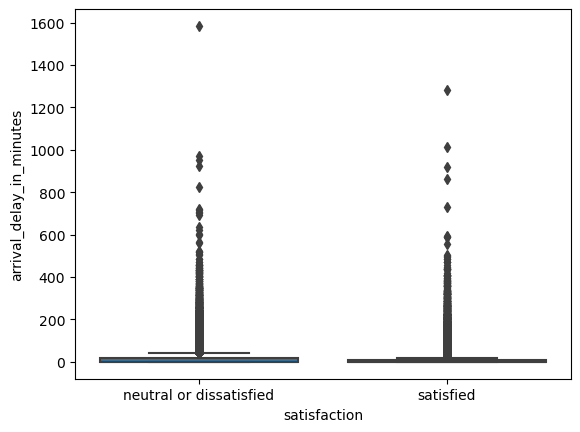

In [38]:
sns.boxplot(
    data=df_clean,
    x="satisfaction",
    y="arrival_delay_in_minutes"
)

In [42]:
df_clean.groupby("satisfaction")["arrival_delay_in_minutes"].describe()

,count,mean,std,min,25%,50%,75%,max
satisfaction,,,,,,,,
neutral or dissatisfied,58879.0,17.197201,40.701368,0.0,0.0,0.0,17.0,1584.0
satisfied,45025.0,12.692282,36.025719,0.0,0.0,0.0,8.0,1280.0


### Age Değişkeninin Satisfaction ile İlişkisi
Müşteri memnuniyeti yaş gruplarına göre değişiyor mu?


Bu bölümde yolcuların yaş dağılımının memnuniyet durumuna göre farklılık gösterip göstermediği incelenmiştir.

Boxplot grafiği incelendiğinde memnun olan yolcuların yaş dağılımının genel olarak daha yüksek değerlere sahip olduğu görülmektedir. Medyan yaş, memnun olan yolcularda daha yukarıda konumlanırken, memnun olmayan yolcuların yaş dağılımı daha genç yaş gruplarında yoğunlaşmaktadır.

Tanımlayıcı istatistikler de bu gözlemi desteklemektedir:

- Memnun olmayan yolcuların ortalama yaşı **37.57**, medyan yaşı ise **36**'dır.
- Memnun olan yolcuların ortalama yaşı **41.75**, medyan yaşı ise **43**'tür.

Yaklaşık **4 yıllık ortalama yaş farkı**, yaş ile müşteri memnuniyeti arasında anlamlı olabilecek bir ilişkinin bulunduğunu göstermektedir.

Ayrıca memnun olmayan yolcularda standart sapmanın (**16.46**) daha yüksek olması, bu grubun yaş açısından daha heterojen bir yapıya sahip olduğunu göstermektedir. Memnun olan yolcularda ise standart sapma (**12.77**) daha düşük olup yaş dağılımı daha homojendir.

Bu bulgular, yaş ilerledikçe müşteri memnuniyetinin artma eğiliminde olabileceğini düşündürmektedir. Ancak bu ilişkinin istatistiksel olarak anlamlı olup olmadığını belirlemek için ilerleyen aşamalarda uygun hipotez testleri uygulanacaktır.



<Axes: xlabel='satisfaction', ylabel='age'>

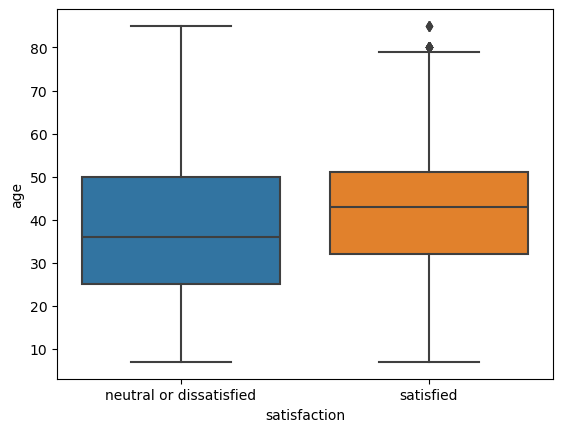

In [39]:
sns.boxplot(
    data=df_clean,
    x="satisfaction",
    y="age"
)

In [43]:
df_clean.groupby("satisfaction")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
satisfaction,,,,,,,,
neutral or dissatisfied,58879.0,37.566688,16.459825,7.0,25.0,36.0,50.0,85.0
satisfied,45025.0,41.750583,12.767833,7.0,32.0,43.0,51.0,85.0


5. Korelasyon Analizi

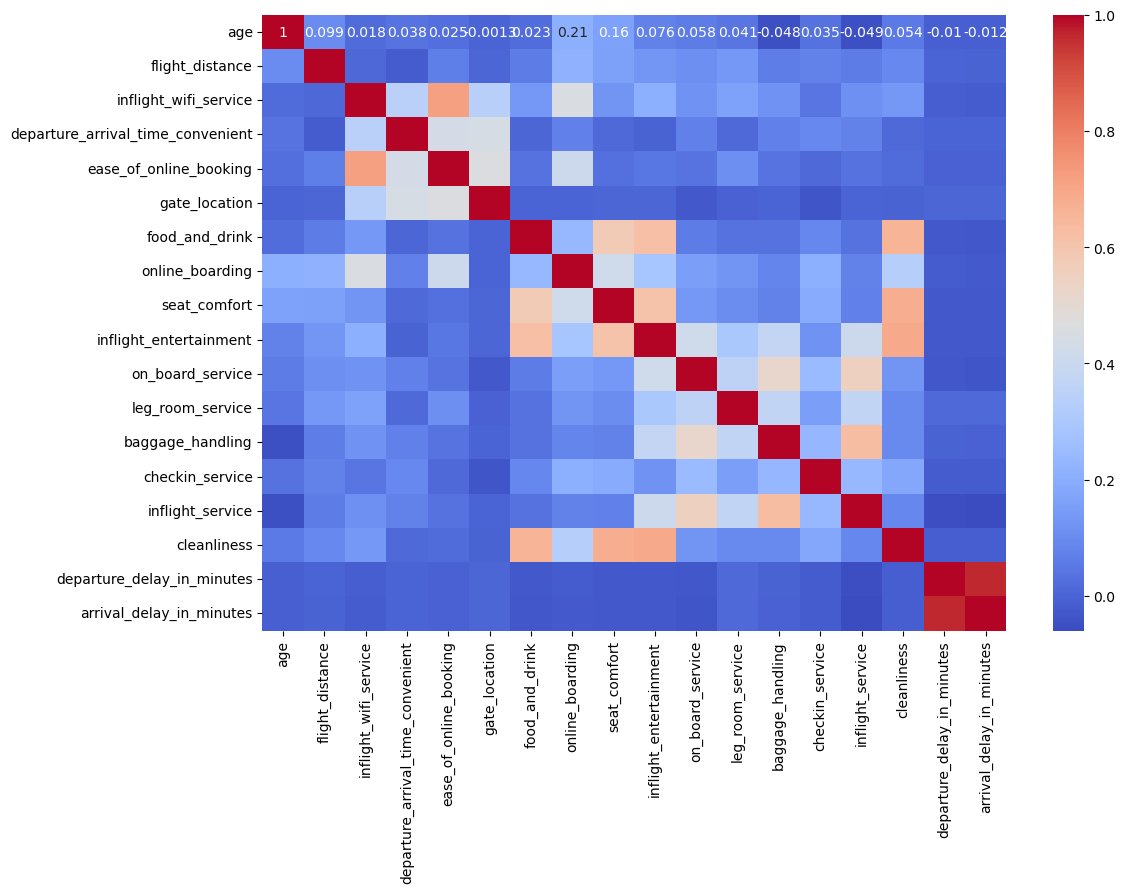

In [53]:
corr = df_clean.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")
plt.show()


Korelasyon Analizi

Bu analizde sayısal değişkenler arasındaki doğrusal ilişkinin yönü ve gücü incelenmiştir. Korelasyon katsayısı -1 ile +1 arasında değer almakta olup, değerin +1'e yaklaşması güçlü pozitif ilişkiyi, -1'e yaklaşması güçlü negatif ilişkiyi, 0'a yaklaşması ise doğrusal bir ilişkinin bulunmadığını göstermektedir.

Heatmap incelendiğinde en güçlü ilişkinin Departure Delay ile Arrival Delay değişkenleri arasında olduğu görülmektedir. Bu durum operasyonel açıdan beklenen bir sonuçtur; kalkışta yaşanan gecikmeler büyük ölçüde varış gecikmesine de yansımaktadır.

Bunun yanında Seat Comfort, Cleanliness, Food and Drink ve Inflight Entertainment gibi hizmet kalitesini temsil eden değişkenler arasında orta ve yüksek düzeyde pozitif korelasyonlar bulunmaktadır. Bu durum, yolcuların uçuş deneyimini tek bir hizmetten ziyade bütünsel olarak değerlendirdiğini düşündürmektedir.

Öte yandan Age ve Flight Distance gibi değişkenlerin hizmet değerlendirmeleriyle olan korelasyonlarının oldukça düşük olduğu görülmektedir. Bu sonuç, bu değişkenlerin tek başına müşteri memnuniyetini açıklamakta yetersiz kalabileceğini göstermektedir.

Bu analiz yalnızca değişkenler arasındaki doğrusal ilişkiyi göstermektedir. İlişkilerin istatistiksel olarak anlamlı olup olmadığı ve müşteri memnuniyeti üzerindeki etkileri, ilerleyen aşamalarda gerçekleştirilecek hipotez testleri ve modelleme çalışmaları ile doğrulanacaktır.

Güçlü İlişkiler
1. Departure Delay ↔ Arrival Delay

Korelasyon Katsayısı: 0.97

İki değişken arasında oldukça güçlü pozitif bir ilişki bulunmaktadır. Uçağın kalkışta gecikmesi arttıkça varış gecikmesinin de benzer şekilde arttığı görülmektedir.

Bu sonuç havacılık operasyonları açısından beklenen bir durumdur. Çünkü kalkışta yaşanan gecikmeler çoğu zaman varış saatini de doğrudan etkilemektedir.

Bu nedenle eksik arrival_delay_in_minutes değerlerinin departure_delay_in_minutes kullanılarak doldurulması metodolojik açıdan da desteklenmektedir.

2. Seat Comfort ↔ Cleanliness

Korelasyon: Yaklaşık 0.68

Koltuk konforu arttıkça temizlik puanlarının da yükseldiği görülmektedir.

Bu durum yolcuların uçuş deneyimini değerlendirirken fiziksel konfor ve kabin temizliğini birlikte değerlendirme eğiliminde olduklarını göstermektedir.

3. Food and Drink ↔ Seat Comfort

Korelasyon: Yaklaşık 0.57

Yiyecek-içecek hizmetinden memnun olan yolcuların koltuk konforunu da daha yüksek puanladıkları görülmektedir.

Bu sonuç, uçuş deneyiminin tek bir hizmetten ziyade birçok hizmetin birleşimi olarak algılandığını göstermektedir.

4. Food and Drink ↔ Cleanliness

Korelasyon: Yaklaşık 0.66

Yiyecek-içecek hizmeti ile temizlik değerlendirmeleri arasında güçlü pozitif ilişki bulunmaktadır.

Kabin hijyeni arttıkça yolcuların ikram hizmetini de daha olumlu değerlendirme eğiliminde oldukları söylenebilir.

5. On-board Service ↔ Inflight Service

Korelasyon: Yaklaşık 0.55

Kabin ekibinin sunduğu genel hizmet ile uçuş sırasındaki hizmet değerlendirmeleri birlikte artmaktadır.

Bu durum, yolcuların kabin personelinin performansını farklı sorularda benzer şekilde değerlendirdiğini göstermektedir.

6. Baggage Handling ↔ Inflight Service

Korelasyon: Yaklaşık 0.53

Bagaj hizmetinden memnun kalan yolcuların uçuş içi hizmetleri de daha olumlu değerlendirdiği görülmektedir.

Bu sonuç, havayolu deneyiminin yalnızca uçuş sırasında değil, seyahatin tüm aşamalarının birlikte değerlendirildiğini göstermektedir.

Genel Değerlendirme

Korelasyon matrisi incelendiğinde en güçlü ilişkinin Departure Delay ile Arrival Delay arasında olduğu görülmektedir. Bunun dışında müşteri deneyimine yönelik hizmet puanları arasında da orta ve yüksek düzeyde pozitif ilişkiler bulunmaktadır.

Bu durum yolcuların uçuş deneyimini birbirinden bağımsız hizmetler yerine bütüncül bir deneyim olarak değerlendirdiğini göstermektedir.

Ancak korelasyon analizi yalnızca değişkenler arasındaki doğrusal ilişkiyi göstermektedir. Bir değişkenin diğerine neden olduğu anlamına gelmez. Değişkenlerin müşteri memnuniyeti üzerindeki etkileri sonraki aşamalarda gerçekleştirilecek hipotez testleri ve modelleme çalışmaları ile daha ayrıntılı olarak değerlendirilecektir.

### HİPOTEZ TESTLERİ 

## 6.1 Age ve Satisfaction

### Araştırma Sorusu
Yaş değişkeni müşteri memnuniyetini etkiliyor mu?

### Hipotezler

**H₀ (Null Hipotezi):** Memnun olan ve memnun olmayan yolcuların yaş dağılımları arasında istatistiksel olarak anlamlı bir fark yoktur.
**H₁ (Alternatif Hipotez):** Memnun olan ve memnun olmayan yolcuların yaş dağılımları arasında istatistiksel olarak anlamlı bir fark vardır.



## 6.2 Flight Distance ve Satisfaction

### Araştırma Sorusu
Uçuş mesafesi müşteri memnuniyetini etkiliyor mu?

### Hipotezler

**H₀ (Null Hipotezi):** Memnun olan ve memnun olmayan yolcuların uçuş mesafeleri arasında istatistiksel olarak anlamlı bir fark yoktur.

**H₁ (Alternatif Hipotez):** Memnun olan ve memnun olmayan yolcuların uçuş mesafeleri arasında istatistiksel olarak anlamlı bir fark vardır.

## 6.3 Departure Delay ve Satisfaction

### Araştırma Sorusu
Kalkış gecikmesi müşteri memnuniyetini etkiliyor mu?

### Hipotezler

**H₀ (Null Hipotezi):** Memnun olan ve memnun olmayan yolcuların kalkış gecikmesi süreleri arasında istatistiksel olarak anlamlı bir fark yoktur.

**H₁ (Alternatif Hipotez):** Memnun olan ve memnun olmayan yolcuların kalkış gecikmesi süreleri arasında istatistiksel olarak anlamlı bir fark vardır.

## 6.4 Arrival Delay ve Satisfaction

### Araştırma Sorusu
Varış gecikmesi müşteri memnuniyetini etkiliyor mu?

### Hipotezler

**H₀ (Null Hipotezi):** Memnun olan ve memnun olmayan yolcuların varış gecikmesi süreleri arasında istatistiksel olarak anlamlı bir fark yoktur.

**H₁ (Alternatif Hipotez):** Memnun olan ve memnun olmayan yolcuların varış gecikmesi süreleri arasında istatistiksel olarak anlamlı bir fark vardır.

## 6.5 Customer Type ve Satisfaction

### Araştırma Sorusu
Müşteri tipi müşteri memnuniyetini etkiliyor mu?

### Hipotezler

**H₀ (Null Hipotezi):** Müşteri tipi ile müşteri memnuniyeti arasında istatistiksel olarak anlamlı bir ilişki yoktur.

**H₁ (Alternatif Hipotez):** Müşteri tipi ile müşteri memnuniyeti arasında istatistiksel olarak anlamlı bir ilişki vardır.

## 6.6 Type of Travel ve Satisfaction

### Araştırma Sorusu
Seyahat amacı müşteri memnuniyetini etkiliyor mu?

### Hipotezler

**H₀ (Null Hipotezi):** Seyahat amacı ile müşteri memnuniyeti arasında istatistiksel olarak anlamlı bir ilişki yoktur.

**H₁ (Alternatif Hipotez):** Seyahat amacı ile müşteri memnuniyeti arasında istatistiksel olarak anlamlı bir ilişki vardır.

## 6.7 Class ve Satisfaction

### Araştırma Sorusu
Uçuş sınıfı müşteri memnuniyetini etkiliyor mu?

### Hipotezler

**H₀ (Null Hipotezi):** Uçuş sınıfı ile müşteri memnuniyeti arasında istatistiksel olarak anlamlı bir ilişki yoktur.

**H₁ (Alternatif Hipotez):** Uçuş sınıfı ile müşteri memnuniyeti arasında istatistiksel olarak anlamlı bir ilişki vardır.

## 6.8 Gender ve Satisfaction

### Araştırma Sorusu
Cinsiyet müşteri memnuniyetini etkiliyor mu?

### Hipotezler

**H₀ (Null Hipotezi):** Cinsiyet ile müşteri memnuniyeti arasında istatistiksel olarak anlamlı bir ilişki yoktur.

**H₁ (Alternatif Hipotez):** Cinsiyet ile müşteri memnuniyeti arasında istatistiksel olarak anlamlı bir ilişki vardır.